# Production Model: MLN Severity Classification (4 Classes)

## Project Overview

This notebook implements the production deep learning model for classifying Maize Lethal Necrosis (MLN) disease severity into four categories: **HEALTHY**, **Early**, **Moderate**, and **Severe**. Built with PyTorch for better deployment flexibility.

## Target Accuracy: 85%+

## Why PyTorch?

- Better deployment options (TorchScript, ONNX, TorchServe)
- Easier mobile deployment (PyTorch Mobile)
- More flexible model export formats
- Better debugging and development experience

## Experimental Design

We will train **4 experiments** with different hyperparameter configurations:

| Experiment | Name | Learning Rate Stage 2 | Unfrozen Layers | Dropout | L2 Reg |
|------------|------|----------------------|-----------------|---------|--------|
| 1 | Baseline | 1e-5 | 50 | 0.5 | 0.01 |
| 2 | Conservative | 5e-6 | 30 | 0.6 | 0.02 |
| 3 | Aggressive | 2e-5 | 80 | 0.4 | 0.005 |
| 4 | Balanced | 1e-5 | 60 | 0.5 | 0.015 |

## Training Strategy

- **Stage 1**: 15 epochs with frozen ResNet50 base (train classifier head) - *Reduced for faster experimentation*
- **Stage 2**: 30 epochs with unfrozen layers (fine-tuning) - *Reduced for faster experimentation*
- **Early Stopping**: Patience of 15 epochs on validation accuracy
- **Model Checkpointing**: Save best model throughout training
- **Export Formats**: .pt (PyTorch) and .onnx (deployment)

## Section 1: Environment Setup and Imports

Import PyTorch and all required libraries. Configure GPU if available.

In [7]:
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
import json
import os
import copy
import time
import pickle
import warnings
from pathlib import Path
from datetime import datetime
from collections import defaultdict
from tqdm.auto import tqdm

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print("Apple Silicon GPU (MPS) available")
else:
    DEVICE = torch.device('cpu')
    print("No GPU found, using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"Random seed: {SEED}")

# Configure matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

No GPU found, using CPU
PyTorch version: 2.5.1.post108
Device: cpu
Random seed: 42


## Section 2: Experiment Configurations

Define experiment configurations as reusable classes. Each experiment has its own hyperparameter set.

In [9]:
# =============================================================================
# EXPERIMENT CONFIGURATIONS
# =============================================================================

class BaseConfig:
    """Base configuration with shared parameters."""
    
    # Paths
    DATA_DIR = '../mln_labels_v2'
    OUTPUT_DIR = '../models/production'
    
    # Image parameters
    IMG_SIZE = 224
    CHANNELS = 3
    
    # Training parameters
    BATCH_SIZE = 32
    VALIDATION_SPLIT = 0.2
    EPOCHS_STAGE1 = 20  
    EPOCHS_STAGE2 = 30  
    LR_STAGE1 = 1e-3
    MIN_LR = 1e-7
    
    # Early stopping
    PATIENCE_STAGE1 = 10
    PATIENCE_STAGE2 = 15
    
    # Augmentation parameters
    ROTATION_DEGREES = 40
    TRANSLATE = (0.3, 0.3)
    SCALE = (0.7, 1.3)
    BRIGHTNESS = 0.4
    CONTRAST = 0.4
    
    # Focal loss parameters
    FOCAL_GAMMA = 2.0
    FOCAL_ALPHA = 0.25
    
    # Class names (4 classes)
    CLASS_NAMES = ['Early', 'HEALTHY', 'Moderate', 'Severe']
    NUM_CLASSES = 4
    
    # Random seed
    SEED = 42
    
    # Number of workers for data loading
    NUM_WORKERS = 0  # Set to 0 for macOS compatibility


class ExperimentConfig:
    """Factory for creating experiment-specific configurations."""
    
    EXPERIMENTS = {
        'baseline': {
            'name': 'Baseline',
            'description': 'Previous best configuration from 3-class model',
            'LR_STAGE2': 1e-5,
            'UNFREEZE_LAYERS': 50,
            'DROPOUT_RATE': 0.5,
            'L2_REGULARIZATION': 0.01,
            'DENSE_UNITS': 256
        },
        'conservative': {
            'name': 'Conservative',
            'description': 'Lower risk of overfitting, stronger regularization',
            'LR_STAGE2': 5e-6,
            'UNFREEZE_LAYERS': 30,
            'DROPOUT_RATE': 0.6,
            'L2_REGULARIZATION': 0.02,
            'DENSE_UNITS': 256
        },
        'aggressive': {
            'name': 'Aggressive',
            'description': 'Faster learning, more model capacity unfrozen',
            'LR_STAGE2': 2e-5,
            'UNFREEZE_LAYERS': 80,
            'DROPOUT_RATE': 0.4,
            'L2_REGULARIZATION': 0.005,
            'DENSE_UNITS': 512
        },
        'balanced': {
            'name': 'Balanced',
            'description': 'Middle ground between conservative and aggressive',
            'LR_STAGE2': 1e-5,
            'UNFREEZE_LAYERS': 60,
            'DROPOUT_RATE': 0.5,
            'L2_REGULARIZATION': 0.015,
            'DENSE_UNITS': 256
        }
    }
    
    @classmethod
    def get_config(cls, experiment_name):
        """Create a configuration object for the specified experiment."""
        if experiment_name not in cls.EXPERIMENTS:
            raise ValueError(f"Unknown experiment: {experiment_name}")
        
        exp = cls.EXPERIMENTS[experiment_name]
        
        class Config(BaseConfig):
            EXPERIMENT_NAME = experiment_name
            EXPERIMENT_DISPLAY_NAME = exp['name']
            EXPERIMENT_DESCRIPTION = exp['description']
            LR_STAGE2 = exp['LR_STAGE2']
            UNFREEZE_LAYERS = exp['UNFREEZE_LAYERS']
            DROPOUT_RATE = exp['DROPOUT_RATE']
            L2_REGULARIZATION = exp['L2_REGULARIZATION']
            DENSE_UNITS = exp['DENSE_UNITS']
            CHECKPOINT_STAGE1 = f'../models/production/{experiment_name}_stage1.pt'
            CHECKPOINT_FINAL = f'../models/production/{experiment_name}_final.pt'
        
        return Config()
    
    @classmethod
    def print_all_experiments(cls):
        """Print summary of all available experiments."""
        print("=" * 85)
        print("AVAILABLE EXPERIMENTS")
        print("=" * 85)
        print(f"{'Name':<15} {'LR Stage2':<12} {'Unfreeze':<10} {'Dropout':<10} {'L2 Reg':<10} {'Dense':<8}")
        print("-" * 85)
        for key, exp in cls.EXPERIMENTS.items():
            print(f"{exp['name']:<15} {exp['LR_STAGE2']:<12.0e} {exp['UNFREEZE_LAYERS']:<10} "
                  f"{exp['DROPOUT_RATE']:<10.2f} {exp['L2_REGULARIZATION']:<10.3f} {exp['DENSE_UNITS']:<8}")
        print("=" * 85)
        print(f"\nTraining: Stage 1 = {BaseConfig.EPOCHS_STAGE1} epochs, Stage 2 = {BaseConfig.EPOCHS_STAGE2} epochs")
        print(f"Early Stopping: Stage 1 = {BaseConfig.PATIENCE_STAGE1}, Stage 2 = {BaseConfig.PATIENCE_STAGE2}")


ExperimentConfig.print_all_experiments()
os.makedirs(BaseConfig.OUTPUT_DIR, exist_ok=True)
print(f"\nOutput directory: {BaseConfig.OUTPUT_DIR}")

AVAILABLE EXPERIMENTS
Name            LR Stage2    Unfreeze   Dropout    L2 Reg     Dense   
-------------------------------------------------------------------------------------
Baseline        1e-05        50         0.50       0.010      256     
Conservative    5e-06        30         0.60       0.020      256     
Aggressive      2e-05        80         0.40       0.005      512     
Balanced        1e-05        60         0.50       0.015      256     

Training: Stage 1 = 20 epochs, Stage 2 = 30 epochs
Early Stopping: Stage 1 = 10, Stage 2 = 15

Output directory: ../models/production


## Section 3: Utility Functions

Define reusable functions for data validation and loss functions.

In [10]:
# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================

def validate_image(image_path, min_size=50):
    """Validate that an image file is readable."""
    try:
        with Image.open(image_path) as img:
            img.verify()
        with Image.open(image_path) as img:
            width, height = img.size
            if width < min_size or height < min_size:
                return False, f"Image too small: {width}x{height}"
        return True, None
    except Exception as e:
        return False, str(e)


def scan_dataset(data_dir, class_names=None):
    """Scan dataset directory and count images per class."""
    stats = {'total_images': 0, 'valid_images': 0, 'invalid_images': 0, 
             'class_counts': {}, 'invalid_files': []}
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        if class_names and class_name not in class_names:
            continue
        
        valid_count = 0
        for filename in os.listdir(class_path):
            ext = os.path.splitext(filename)[1].lower()
            if ext not in valid_extensions:
                continue
            stats['total_images'] += 1
            image_path = os.path.join(class_path, filename)
            is_valid, error = validate_image(image_path)
            if is_valid:
                valid_count += 1
                stats['valid_images'] += 1
            else:
                stats['invalid_images'] += 1
                stats['invalid_files'].append((image_path, error))
        stats['class_counts'][class_name] = valid_count
    return stats


class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance."""
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss


class EarlyStopping:
    """Early stopping to stop training when validation accuracy stops improving."""
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None
    
    def __call__(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            self.best_model_state = copy.deepcopy(model.state_dict())
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.early_stop = True
        return False
    
    def restore_best_model(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)


def get_cosine_schedule_with_warmup(optimizer, warmup_epochs, total_epochs, min_lr=1e-7):
    """Create cosine annealing schedule with linear warmup."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return max(min_lr, 0.5 * (1 + np.cos(np.pi * progress)))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


print("Utility functions defined successfully")

Utility functions defined successfully


## Section 4: Visualization Functions

Define plotting functions for training monitoring and evaluation.

In [11]:
# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_class_distribution(class_counts, title="Class Distribution"):
    """Plot class distribution as bar and pie charts."""
    if isinstance(class_counts, dict):
        class_counts = pd.Series(class_counts)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#3498db', '#27ae60', '#f39c12', '#e74c3c']
    
    class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', alpha=0.8)
    axes[0].set_title(f'{title} - Counts', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Class', fontsize=12)
    axes[0].set_ylabel('Number of Images', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    for i, (idx, val) in enumerate(class_counts.items()):
        axes[0].text(i, val + 50, str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
                colors=colors, explode=[0.02]*len(class_counts), shadow=True)
    axes[1].set_title(f'{title} - Percentage', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    return fig


def plot_training_history(history, title="Training History", save_path=None):
    """Plot training history: accuracy, loss, and learning rate."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_acc']) + 1)
    
    axes[0].plot(epochs, history['train_acc'], 'b-', label='Training', linewidth=2)
    axes[0].plot(epochs, history['val_acc'], 'r-', label='Validation', linewidth=2)
    axes[0].axhline(y=0.85, color='g', linestyle='--', label='Target (85%)', alpha=0.7)
    axes[0].set_title(f'{title} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0, 1])
    
    axes[1].plot(epochs, history['train_loss'], 'b-', label='Training', linewidth=2)
    axes[1].plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[1].set_title(f'{title} - Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    if 'lr' in history:
        axes[2].plot(epochs, history['lr'], 'purple', linewidth=2)
        axes[2].set_title(f'{title} - Learning Rate', fontsize=14, fontweight='bold')
        axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
        axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0], annot_kws={'size': 12})
    axes[0].set_title(f'{title} (Counts)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
    
    sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1], annot_kws={'size': 12})
    axes[1].set_title(f'{title} (Normalized)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()
    return fig, cm, cm_normalized


def plot_experiment_comparison(results_dict):
    """Compare multiple experiments."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
    
    for i, (name, results) in enumerate(results_dict.items()):
        if 'history' in results:
            history = results['history']
            epochs = range(1, len(history['val_acc']) + 1)
            axes[0].plot(epochs, history['val_acc'], label=name, color=colors[i % len(colors)], linewidth=2)
    
    axes[0].axhline(y=0.85, color='gray', linestyle='--', label='Target (85%)', alpha=0.7)
    axes[0].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0.5, 1.0])
    
    names = list(results_dict.keys())
    accuracies = [results_dict[n].get('best_val_accuracy', 0) for n in names]
    bars = axes[1].bar(names, accuracies, color=colors[:len(names)], edgecolor='black', alpha=0.8)
    axes[1].axhline(y=0.85, color='gray', linestyle='--', alpha=0.7)
    axes[1].set_title('Best Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Accuracy'); axes[1].set_ylim([0.7, 1.0])
    for bar, acc in zip(bars, accuracies):
        axes[1].text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.1%}', 
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    return fig


print("Visualization functions defined successfully")

Visualization functions defined successfully


## Section 5: Data Loading with PyTorch

Create PyTorch datasets and data loaders with augmentation.

In [12]:
# =============================================================================
# DATA LOADING
# =============================================================================

def create_data_loaders(data_dir, config, validation_split=0.2):
    """Create training and validation data loaders."""
    # ImageNet normalization
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    # Training transforms
    train_transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE + 32, config.IMG_SIZE + 32)),
        transforms.RandomCrop(config.IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(config.ROTATION_DEGREES),
        transforms.ColorJitter(brightness=config.BRIGHTNESS, contrast=config.CONTRAST),
        transforms.ToTensor(),
        normalize
    ])
    
    # Validation transforms
    val_transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ToTensor(),
        normalize
    ])
    
    # Load dataset
    full_dataset = ImageFolder(data_dir, transform=train_transform)
    class_names = full_dataset.classes
    
    # Split
    total_size = len(full_dataset)
    val_size = int(total_size * validation_split)
    train_size = total_size - val_size
    
    generator = torch.Generator().manual_seed(config.SEED)
    train_indices, val_indices = random_split(range(total_size), [train_size, val_size], generator=generator)
    
    # Create datasets
    train_dataset = torch.utils.data.Subset(ImageFolder(data_dir, transform=train_transform), train_indices.indices)
    val_dataset = torch.utils.data.Subset(ImageFolder(data_dir, transform=val_transform), val_indices.indices)
    
    # Calculate class weights
    train_labels = [full_dataset.targets[i] for i in train_indices.indices]
    class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
    class_weights = torch.FloatTensor(class_weights).to(DEVICE)
    
    # Create loaders
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, 
                             num_workers=config.NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                           num_workers=config.NUM_WORKERS, pin_memory=True)
    
    return train_loader, val_loader, class_names, class_weights


print("Data loading functions defined successfully")

Data loading functions defined successfully


## Section 6: Model Architecture (ResNet50)

Build CNN model using transfer learning with ResNet50.

In [13]:
# =============================================================================
# MODEL ARCHITECTURE
# =============================================================================

class MLNClassifier(nn.Module):
    """MLN Severity Classifier using ResNet50 as backbone."""
    
    def __init__(self, num_classes, dropout_rate=0.5, dense_units=256):
        super().__init__()
        self.base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()
        
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(num_features),
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, dense_units),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(dense_units, num_classes)
        )
        self.num_classes = num_classes
        self.num_features = num_features
    
    def forward(self, x):
        features = self.base_model(x)
        return self.classifier(features)
    
    def freeze_base(self):
        for param in self.base_model.parameters():
            param.requires_grad = False
    
    def unfreeze_layers(self, num_layers):
        for param in self.base_model.parameters():
            param.requires_grad = False
        modules = list(self.base_model.modules())
        unfrozen = 0
        for module in reversed(modules):
            if unfrozen >= num_layers:
                break
            for param in module.parameters(recurse=False):
                param.requires_grad = True
                unfrozen += 1
        return unfrozen
    
    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable


def build_model(config, freeze_base=True):
    """Build the MLN classifier model."""
    model = MLNClassifier(config.NUM_CLASSES, config.DROPOUT_RATE, config.DENSE_UNITS)
    if freeze_base:
        model.freeze_base()
    return model.to(DEVICE)


def print_model_summary(model, config):
    """Print model summary."""
    total, trainable = model.count_parameters()
    print("=" * 60)
    print("MODEL ARCHITECTURE")
    print("=" * 60)
    print(f"Experiment:            {config.EXPERIMENT_DISPLAY_NAME}")
    print(f"Base Model:            ResNet50")
    print(f"Output Classes:        {model.num_classes}")
    print(f"Dense Units:           {config.DENSE_UNITS}")
    print(f"Dropout Rate:          {config.DROPOUT_RATE}")
    print(f"Total Parameters:      {total:,}")
    print(f"Trainable Parameters:  {trainable:,}")
    print("=" * 60)


print("Model architecture defined successfully")

Model architecture defined successfully


## Section 7: Training Functions

Training functions with early stopping and model checkpointing.

In [14]:
# =============================================================================
# TRAINING FUNCTIONS
# =============================================================================

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in tqdm(train_loader, desc='Training', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / total, correct / total


def validate(model, val_loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='Validating', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / total, correct / total


def train_stage(model, train_loader, val_loader, config, stage, class_weights, checkpoint_path):
    """Train a single stage."""
    if stage == 1:
        epochs, lr, patience = config.EPOCHS_STAGE1, config.LR_STAGE1, config.PATIENCE_STAGE1
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        print(f"\nStage 1: Training classifier head (base frozen)")
    else:
        epochs, lr, patience = config.EPOCHS_STAGE2, config.LR_STAGE2, config.PATIENCE_STAGE2
        criterion = FocalLoss(gamma=config.FOCAL_GAMMA, alpha=class_weights)
        print(f"\nStage 2: Fine-tuning with {config.UNFREEZE_LAYERS} unfrozen layers")
    
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                           lr=lr, weight_decay=config.L2_REGULARIZATION)
    scheduler = get_cosine_schedule_with_warmup(optimizer, 5, epochs, config.MIN_LR)
    early_stopping = EarlyStopping(patience=patience)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    
    print(f"Training for up to {epochs} epochs with patience {patience}")
    print("-" * 70)
    
    for epoch in range(epochs):
        start_time = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        is_best = early_stopping(val_acc, model)
        if is_best:
            best_val_acc = val_acc
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                       'val_acc': val_acc, 'config': config.EXPERIMENT_NAME}, checkpoint_path)
        
        elapsed = time.time() - start_time
        save_marker = ' [SAVED]' if is_best else ''
        print(f"Epoch {epoch+1:3d}/{epochs} | Train: {train_loss:.4f}/{train_acc:.4f} | "
              f"Val: {val_loss:.4f}/{val_acc:.4f} | LR: {current_lr:.2e} | {elapsed:.1f}s{save_marker}")
        
        if early_stopping.early_stop:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break
    
    early_stopping.restore_best_model(model)
    print(f"\nStage {stage} Complete! Best Val Accuracy: {best_val_acc:.4f}")
    return history


def run_experiment(experiment_name, train_loader, val_loader, class_weights):
    """Run complete training experiment (Stage 1 + Stage 2)."""
    print("\n" + "#" * 70)
    print(f"# EXPERIMENT: {experiment_name.upper()}")
    print("#" * 70)
    
    config = ExperimentConfig.get_config(experiment_name)
    print(f"\nDescription: {config.EXPERIMENT_DESCRIPTION}")
    
    model = build_model(config, freeze_base=True)
    print_model_summary(model, config)
    
    # Stage 1
    print("\n" + "=" * 70)
    print(f"STAGE 1 TRAINING - {config.EXPERIMENT_DISPLAY_NAME}")
    print("=" * 70)
    history1 = train_stage(model, train_loader, val_loader, config, 1, class_weights, config.CHECKPOINT_STAGE1)
    
    # Stage 2
    print("\n" + "=" * 70)
    print(f"STAGE 2 TRAINING - {config.EXPERIMENT_DISPLAY_NAME}")
    print("=" * 70)
    unfrozen = model.unfreeze_layers(config.UNFREEZE_LAYERS)
    total, trainable = model.count_parameters()
    print(f"Unfrozen {unfrozen} params, {trainable:,} trainable")
    history2 = train_stage(model, train_loader, val_loader, config, 2, class_weights, config.CHECKPOINT_FINAL)
    
    # Combine histories
    combined_history = {k: history1[k] + history2[k] for k in history1.keys()}
    best_val_accuracy = max(combined_history['val_acc'])
    
    print("\n" + "=" * 70)
    print(f"EXPERIMENT COMPLETE: {experiment_name.upper()} - Best: {best_val_accuracy:.1%}")
    print("=" * 70)
    
    return {'model': model, 'config': config, 'history': combined_history, 'best_val_accuracy': best_val_accuracy}


print("Training functions defined successfully")

Training functions defined successfully


## Section 8: Evaluation and Export Functions

Functions for evaluation and saving models in multiple formats (.pt, .onnx).

In [15]:
# =============================================================================
# EVALUATION AND EXPORT
# =============================================================================

def evaluate_model(model, val_loader, class_names, experiment_name="Model"):
    """Evaluate model with full metrics."""
    print(f"\nEvaluating {experiment_name}...")
    model.eval()
    all_preds, all_labels, all_conf = [], [], []
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='Evaluating'):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            confidence, preds = probs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_conf.extend(confidence.cpu().numpy())
    
    y_pred, y_true = np.array(all_preds), np.array(all_labels)
    accuracy = np.mean(y_pred == y_true)
    report_str = classification_report(y_true, y_pred, target_names=class_names)
    
    print(f"\n{'='*60}")
    print(f"EVALUATION RESULTS: {experiment_name}")
    print(f"{'='*60}")
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
    print(f"\n{report_str}")
    
    return {'accuracy': accuracy, 'predictions': y_pred, 'true_labels': y_true, 'confidence_scores': np.array(all_conf)}


def save_model_formats(model, config, class_names, output_dir):
    """Save model in multiple formats."""
    print(f"\nSaving model in multiple formats...")
    model.eval()
    
    # PyTorch .pt
    pt_path = os.path.join(output_dir, 'production_model_best.pt')
    torch.save({'model_state_dict': model.state_dict(), 'class_names': class_names,
                'num_classes': len(class_names), 'config': config.EXPERIMENT_NAME}, pt_path)
    print(f"  PyTorch: {pt_path}")
    
    # Full model
    full_path = os.path.join(output_dir, 'production_model_full.pt')
    torch.save(model, full_path)
    print(f"  Full model: {full_path}")
    
    # ONNX
    onnx_path = os.path.join(output_dir, 'production_model_best.onnx')
    dummy_input = torch.randn(1, 3, config.IMG_SIZE, config.IMG_SIZE).to(DEVICE)
    try:
        torch.onnx.export(model, dummy_input, onnx_path, export_params=True, opset_version=12,
                         input_names=['input'], output_names=['output'],
                         dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}})
        print(f"  ONNX: {onnx_path}")
    except Exception as e:
        print(f"  ONNX export failed: {e}")
    
    # TorchScript
    ts_path = os.path.join(output_dir, 'production_model_scripted.pt')
    try:
        traced = torch.jit.trace(model, dummy_input)
        traced.save(ts_path)
        print(f"  TorchScript: {ts_path}")
    except Exception as e:
        print(f"  TorchScript failed: {e}")


def save_best_model(results_dict, class_names, output_dir):
    """Save best model and metadata."""
    best_exp = max(results_dict.keys(), key=lambda k: results_dict[k]['best_val_accuracy'])
    best = results_dict[best_exp]
    
    print(f"\n{'='*60}")
    print(f"BEST MODEL: {best_exp.upper()} - {best['best_val_accuracy']:.1%}")
    print(f"{'='*60}")
    
    save_model_formats(best['model'], best['config'], class_names, output_dir)
    
    # Metadata
    metadata = {
        'experiment': best_exp, 'accuracy': float(best['best_val_accuracy']),
        'config': {'lr_stage2': best['config'].LR_STAGE2, 'unfreeze_layers': best['config'].UNFREEZE_LAYERS,
                   'dropout': best['config'].DROPOUT_RATE, 'l2': best['config'].L2_REGULARIZATION},
        'class_names': class_names, 'framework': 'pytorch', 'timestamp': datetime.now().isoformat()
    }
    with open(os.path.join(output_dir, 'production_model_metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)
    
    with open(os.path.join(output_dir, 'production_training_history.pkl'), 'wb') as f:
        pickle.dump(best['history'], f)
    
    return best_exp


print("Evaluation and export functions defined successfully")

Evaluation and export functions defined successfully


## Section 9: Data Validation

Load and validate the 4-class dataset.

In [16]:
# =============================================================================
# DATA VALIDATION
# =============================================================================

print("Scanning 4-class dataset...")
print("=" * 60)

dataset_stats = scan_dataset(BaseConfig.DATA_DIR, BaseConfig.CLASS_NAMES)
total = sum(dataset_stats['class_counts'].values())

print(f"Total images: {dataset_stats['total_images']}")
print(f"Valid images: {dataset_stats['valid_images']}")
print(f"Invalid: {dataset_stats['invalid_images']}")
print("\nClass Distribution:")
print("-" * 50)
for name in BaseConfig.CLASS_NAMES:
    count = dataset_stats['class_counts'].get(name, 0)
    pct = (count / total * 100) if total > 0 else 0
    print(f"  {name:12s}: {count:5d} images ({pct:5.1f}%)")
print("-" * 50)
print(f"  {'Total':12s}: {total:5d} images")
print("=" * 60)

Scanning 4-class dataset...
Total images: 6297
Valid images: 6297
Invalid: 0

Class Distribution:
--------------------------------------------------
  Early       :  1398 images ( 22.2%)
  HEALTHY     :  3073 images ( 48.8%)
  Moderate    :   989 images ( 15.7%)
  Severe      :   837 images ( 13.3%)
--------------------------------------------------
  Total       :  6297 images


## Section 10: Visualize Distribution

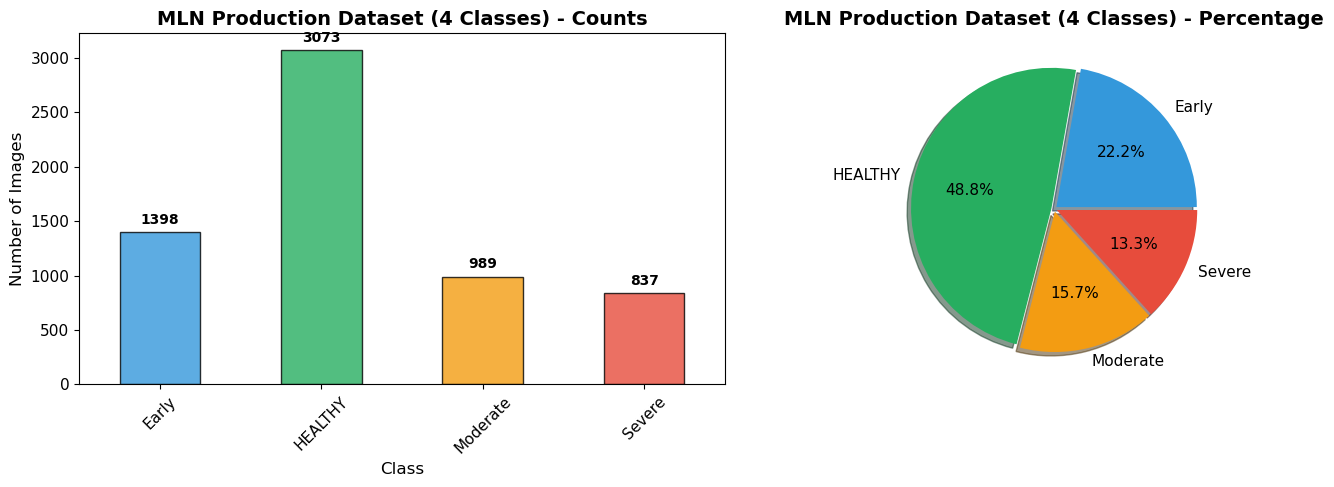

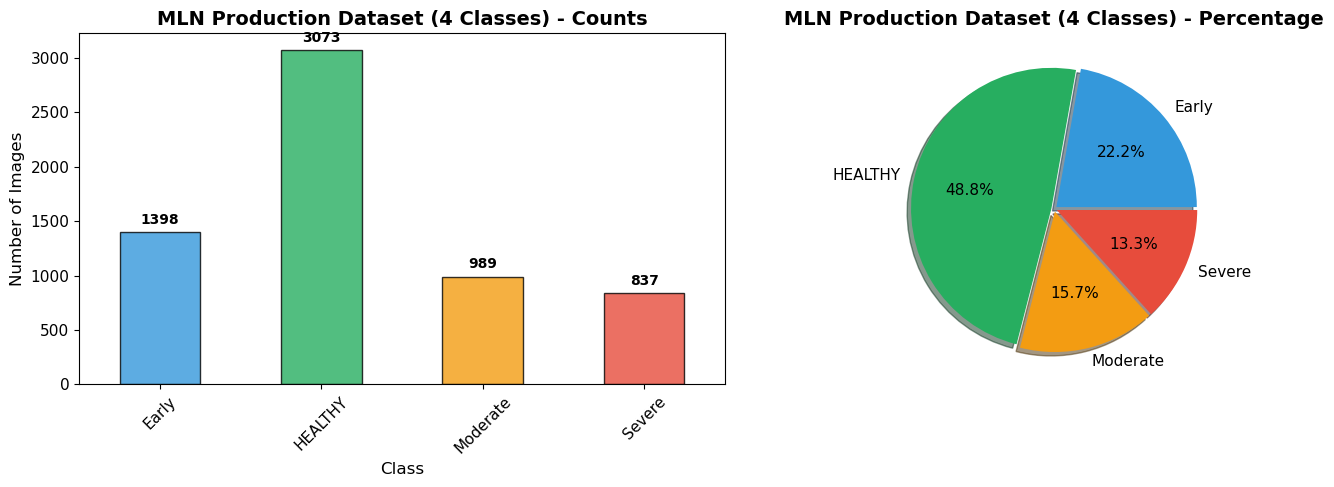

In [17]:
# =============================================================================
# VISUALIZE DISTRIBUTION
# =============================================================================

class_counts = pd.Series(dataset_stats['class_counts'])[BaseConfig.CLASS_NAMES]
plot_class_distribution(class_counts, title="MLN Production Dataset (4 Classes)")

## Section 11: Create Data Loaders

In [18]:
# =============================================================================
# CREATE DATA LOADERS
# =============================================================================

base_config = ExperimentConfig.get_config('baseline')
train_loader, val_loader, class_names, class_weights = create_data_loaders(
    BaseConfig.DATA_DIR, base_config, BaseConfig.VALIDATION_SPLIT
)

print("=" * 60)
print("DATA LOADERS CREATED")
print("=" * 60)
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Batch size:         {BaseConfig.BATCH_SIZE}")
print(f"Classes:            {class_names}")
print("\nClass Weights:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_weights[i].item():.4f}")
print("=" * 60)

DATA LOADERS CREATED
Training batches:   158
Validation batches: 40
Batch size:         32
Classes:            ['Early', 'HEALTHY', 'Moderate', 'Severe']

Class Weights:
  Early: 1.1178
  HEALTHY: 0.5121
  Moderate: 1.6382
  Severe: 1.8444


---
# EXPERIMENT TRAINING

Run each experiment one at a time. **Stage 1: 15 epochs, Stage 2: 30 epochs.**

---

## Section 12: Experiment 1 - Baseline


######################################################################
# EXPERIMENT: BASELINE
######################################################################

Description: Previous best configuration from 3-class model
MODEL ARCHITECTURE
Experiment:            Baseline
Base Model:            ResNet50
Output Classes:        4
Dense Units:           256
Dropout Rate:          0.5
Total Parameters:      24,037,700
Trainable Parameters:  529,668

STAGE 1 TRAINING - Baseline

Stage 1: Training classifier head (base frozen)
Training for up to 20 epochs with patience 10
----------------------------------------------------------------------


Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch   1/20 | Train: 0.9112/0.6859 | Val: 0.7038/0.7919 | LR: 2.00e-04 | 636.5s [SAVED]


Training:   0%|          | 0/158 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch  19/30 | Train: 0.2908/0.8329 | Val: 0.2616/0.8681 | LR: 4.69e-06 | 840.0s


Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch  20/30 | Train: 0.2738/0.8438 | Val: 0.2618/0.8618 | LR: 4.06e-06 | 849.9s

Early stopping triggered at epoch 20

Stage 2 Complete! Best Val Accuracy: 0.8674

EXPERIMENT COMPLETE: BASELINE - Best: 86.8%


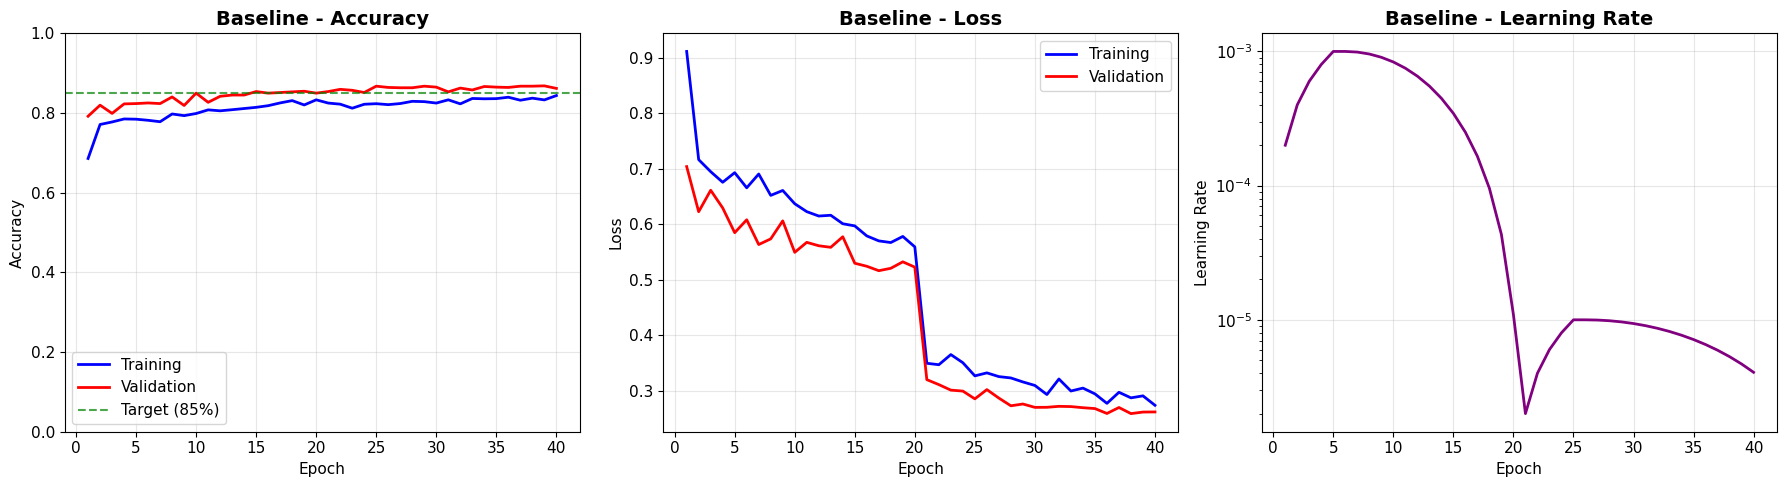

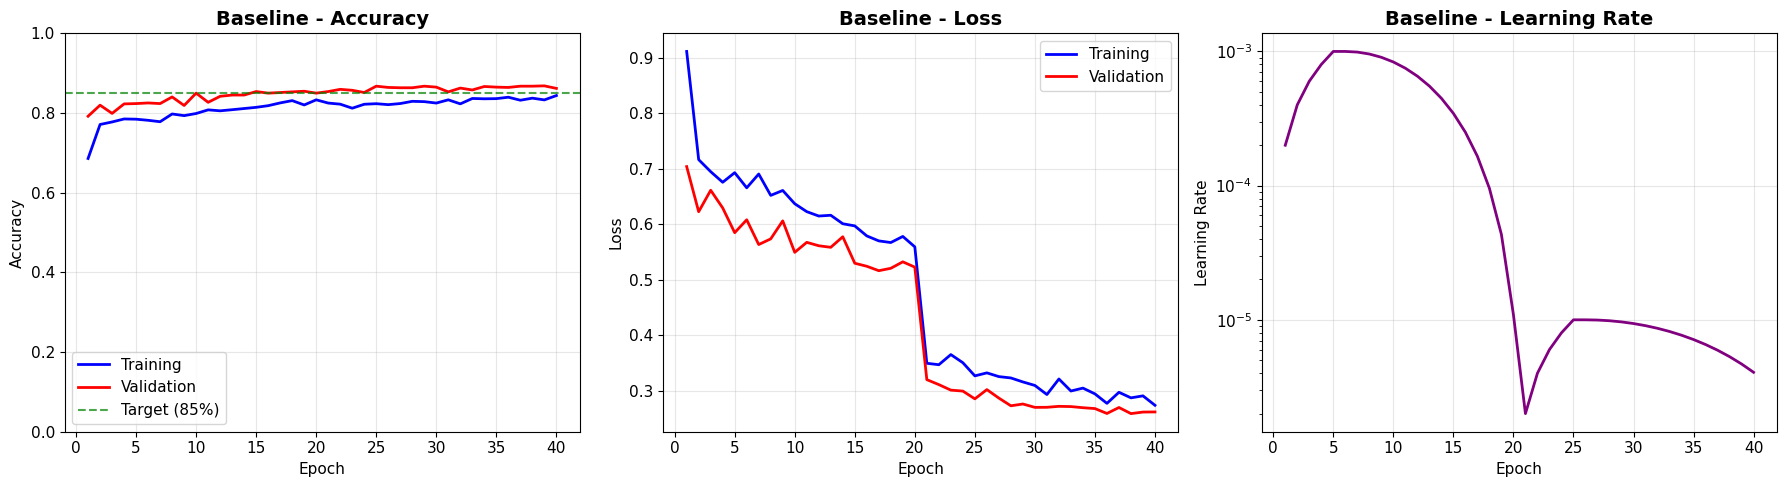

In [19]:
experiment_results = {}
experiment_results['baseline'] = run_experiment('baseline', train_loader, val_loader, class_weights)
plot_training_history(experiment_results['baseline']['history'], title="Baseline")


BASELINE EXPERIMENT - STAGE 1 EVALUATION

Experiment: Baseline
Description: Previous best configuration from 3-class model
Best Validation Accuracy: 0.8681 (86.81%)

---------------------------------------------------------------------------
GENERATING PREDICTIONS ON VALIDATION SET...
---------------------------------------------------------------------------


Evaluating Baseline:   0%|          | 0/40 [00:00<?, ?it/s]


OVERALL METRICS
Accuracy:  0.8674 (86.74%)
Precision: 0.8701 (87.01%)
Recall:    0.8674 (86.74%)
F1-Score:  0.8679 (86.79%)

PER-CLASS METRICS
              precision    recall  f1-score   support

       Early     0.8044    0.8044    0.8044       271
     HEALTHY     0.9984    0.9935    0.9959       613
    Moderate     0.6612    0.7364    0.6968       220
      Severe     0.7744    0.6645    0.7153       155

    accuracy                         0.8674      1259
   macro avg     0.8096    0.7997    0.8031      1259
weighted avg     0.8701    0.8674    0.8679      1259


CONFUSION MATRIX (Raw Counts)

True \ Pred       Early    HEALTHY   Moderate     Severe
---------------------------------------------------------------------------
Early               218          0         49          4
HEALTHY               2        609          0          2
Moderate             34          0        162         24
Severe               17          1         34        103

CONFUSION MATRIX (Percentag

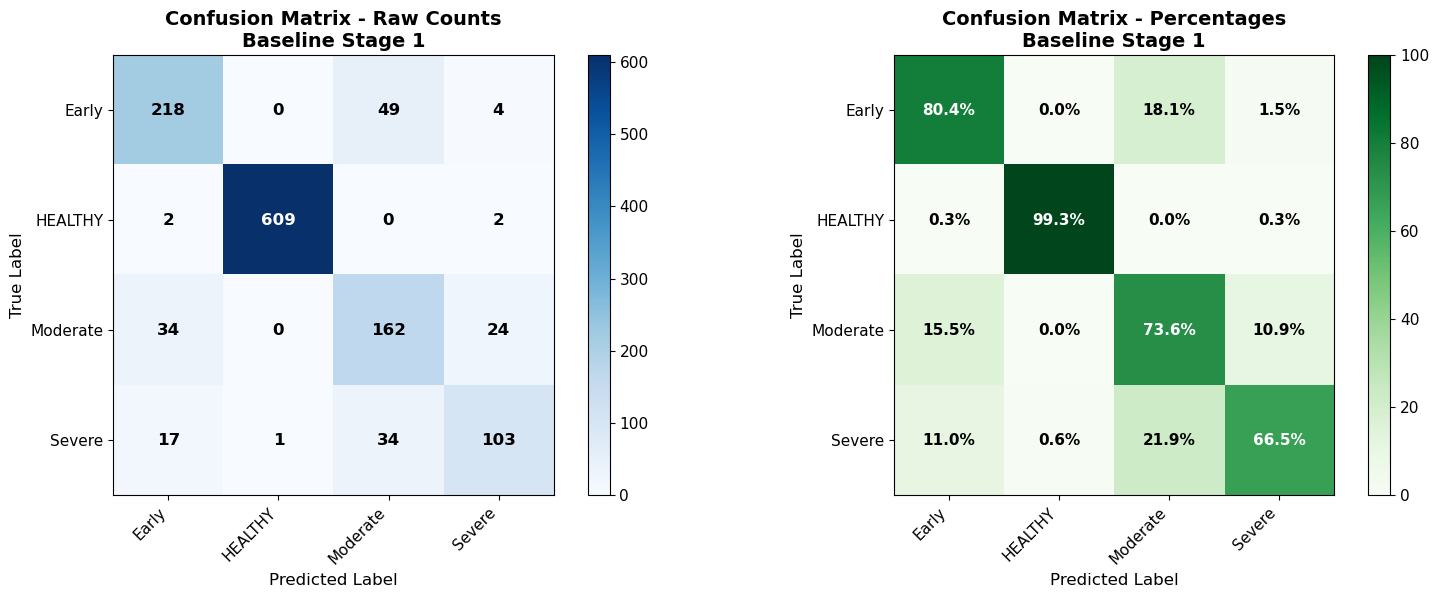


CLASS-WISE ACCURACY
Early       :  80.44% ( 218/ 271 correct)
HEALTHY     :  99.35% ( 609/ 613 correct)
Moderate    :  73.64% ( 162/ 220 correct)
Severe      :  66.45% ( 103/ 155 correct)

TOP MISCLASSIFICATIONS

True Class   -> Predicted As    Count    % of True
---------------------------------------------------------------------------
Early        -> Moderate           49        18.1%
Moderate     -> Early              34        15.5%
Severe       -> Moderate           34        21.9%
Moderate     -> Severe             24        10.9%
Severe       -> Early              17        11.0%
Early        -> Severe              4         1.5%
HEALTHY      -> Early               2         0.3%
HEALTHY      -> Severe              2         0.3%
Severe       -> HEALTHY             1         0.6%

BASELINE STAGE 1 EVALUATION COMPLETE


In [21]:
# =============================================================================
# BASELINE EXPERIMENT - DETAILED EVALUATION
# =============================================================================

# Import additional sklearn metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n" + "=" * 75)
print("BASELINE EXPERIMENT - STAGE 1 EVALUATION")
print("=" * 75)

# Get the baseline model and results
baseline_model = experiment_results['baseline']['model']
baseline_config = experiment_results['baseline']['config']
baseline_history = experiment_results['baseline']['history']

# Print training summary
print(f"\nExperiment: {baseline_config.EXPERIMENT_DISPLAY_NAME}")
print(f"Description: {baseline_config.EXPERIMENT_DESCRIPTION}")
print(f"Best Validation Accuracy: {experiment_results['baseline']['best_val_accuracy']:.4f} ({experiment_results['baseline']['best_val_accuracy']*100:.2f}%)")

# Evaluate on validation set
print("\n" + "-" * 75)
print("GENERATING PREDICTIONS ON VALIDATION SET...")
print("-" * 75)

baseline_model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc='Evaluating Baseline'):
        inputs = inputs.to(DEVICE)
        outputs = baseline_model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = probs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)
y_probs = np.array(all_probs)

# Overall metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n" + "=" * 75)
print("OVERALL METRICS")
print("=" * 75)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

# Per-class metrics
print("\n" + "=" * 75)
print("PER-CLASS METRICS")
print("=" * 75)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\n" + "=" * 75)
print("CONFUSION MATRIX (Raw Counts)")
print("=" * 75)
print(f"\nTrue \\ Pred  {' '.join([f'{name:>10s}' for name in class_names])}")
print("-" * 75)
for i, true_class in enumerate(class_names):
    counts = ' '.join([f'{cm[i][j]:>10d}' for j in range(len(class_names))])
    print(f"{true_class:<12s} {counts}")

# Confusion Matrix (Percentages)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
print("\n" + "=" * 75)
print("CONFUSION MATRIX (Percentages)")
print("=" * 75)
print(f"\nTrue \\ Pred  {' '.join([f'{name:>10s}' for name in class_names])}")
print("-" * 75)
for i, true_class in enumerate(class_names):
    percentages = ' '.join([f'{cm_percent[i][j]:>9.1f}%' for j in range(len(class_names))])
    print(f"{true_class:<12s} {percentages}")

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
im1 = axes[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix - Raw Counts\nBaseline Stage 1', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
tick_marks = np.arange(len(class_names))
axes[0].set_xticks(tick_marks)
axes[0].set_yticks(tick_marks)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_yticklabels(class_names)

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=12, fontweight='bold')

plt.colorbar(im1, ax=axes[0])

# Percentages
im2 = axes[1].imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Greens, vmin=0, vmax=100)
axes[1].set_title('Confusion Matrix - Percentages\nBaseline Stage 1', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_yticklabels(class_names)

# Add text annotations
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        axes[1].text(j, i, f'{cm_percent[i, j]:.1f}%',
                    ha="center", va="center",
                    color="white" if cm_percent[i, j] > 50 else "black",
                    fontsize=11, fontweight='bold')

plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()

# Class-wise accuracy
print("\n" + "=" * 75)
print("CLASS-WISE ACCURACY")
print("=" * 75)
for i, class_name in enumerate(class_names):
    class_acc = cm[i, i] / cm[i].sum() * 100
    print(f"{class_name:<12s}: {class_acc:>6.2f}% ({cm[i, i]:>4d}/{cm[i].sum():>4d} correct)")

# Misclassification analysis
print("\n" + "=" * 75)
print("TOP MISCLASSIFICATIONS")
print("=" * 75)
misclass_counts = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            misclass_counts.append((class_names[i], class_names[j], cm[i, j]))

misclass_counts.sort(key=lambda x: x[2], reverse=True)
print(f"\n{'True Class':<12s} -> {'Predicted As':<12s} {'Count':>8s} {'% of True':>12s}")
print("-" * 75)
for true_class, pred_class, count in misclass_counts[:10]:
    true_idx = class_names.index(true_class)
    percent = count / cm[true_idx].sum() * 100
    print(f"{true_class:<12s} -> {pred_class:<12s} {count:>8d} {percent:>11.1f}%")

print("\n" + "=" * 75)
print(f"BASELINE STAGE 1 EVALUATION COMPLETE")
print("=" * 75)

### Baseline - Detailed Evaluation & Confusion Matrix

Evaluate Baseline experiment with confusion matrix and per-class metrics.

## Section 13: Experiment 2 - Conservative

In [ ]:
experiment_results['conservative'] = run_experiment('conservative', train_loader, val_loader, class_weights)
plot_training_history(experiment_results['conservative']['history'], title="Conservative")

## Section 14: Experiment 3 - Aggressive

In [ ]:
experiment_results['aggressive'] = run_experiment('aggressive', train_loader, val_loader, class_weights)
plot_training_history(experiment_results['aggressive']['history'], title="Aggressive")

## Section 15: Experiment 4 - Balanced

In [ ]:
experiment_results['balanced'] = run_experiment('balanced', train_loader, val_loader, class_weights)
plot_training_history(experiment_results['balanced']['history'], title="Balanced")

---
# COMPARISON AND MODEL SELECTION

---

## Section 16: Compare All Experiments

In [ ]:
print("=" * 75)
print("EXPERIMENT COMPARISON")
print("=" * 75)
print(f"{'Experiment':<15} {'Best Val Acc':<15} {'LR Stage2':<12} {'Status'}")
print("-" * 75)
for name, results in experiment_results.items():
    acc = results['best_val_accuracy']
    lr = results['config'].LR_STAGE2
    status = "TARGET MET" if acc >= 0.85 else "Below target"
    print(f"{name:<15} {acc:<15.4f} {lr:<12.0e} {status}")
print("=" * 75)

best_exp = max(experiment_results.keys(), key=lambda k: experiment_results[k]['best_val_accuracy'])
print(f"\nBest: {best_exp.upper()} with {experiment_results[best_exp]['best_val_accuracy']:.1%}")

plot_experiment_comparison(experiment_results)

## Section 17: Evaluate Best Model

In [ ]:
best_exp = max(experiment_results.keys(), key=lambda k: experiment_results[k]['best_val_accuracy'])
best_model = experiment_results[best_exp]['model']

eval_results = evaluate_model(best_model, val_loader, class_names, f"Best ({best_exp})")
plot_confusion_matrix(eval_results['true_labels'], eval_results['predictions'], class_names, f"Confusion Matrix - {best_exp}")

## Section 18: Save Best Model (Multiple Formats)

In [ ]:
save_best_model(experiment_results, class_names, BaseConfig.OUTPUT_DIR)

print("\nFiles saved:")
for f in sorted(os.listdir(BaseConfig.OUTPUT_DIR)):
    fpath = os.path.join(BaseConfig.OUTPUT_DIR, f)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / (1024*1024)
        print(f"  - {f} ({size:.1f} MB)")

## Section 19: Final Summary

In [ ]:
best_exp = max(experiment_results.keys(), key=lambda k: experiment_results[k]['best_val_accuracy'])
best_acc = experiment_results[best_exp]['best_val_accuracy']
best_config = experiment_results[best_exp]['config']

print("\n" + "#" * 75)
print("#" + " " * 20 + "PRODUCTION MODEL TRAINING COMPLETE" + " " * 18 + "#")
print("#" * 75)
print(f"\nFRAMEWORK: PyTorch {torch.__version__}")
print(f"DEVICE: {DEVICE}")
print(f"\nDATASET: {', '.join(class_names)} ({total:,} images)")
print(f"TRAINING: Stage 1 = {BaseConfig.EPOCHS_STAGE1} epochs, Stage 2 = {BaseConfig.EPOCHS_STAGE2} epochs")
print(f"\nEXPERIMENTS:")
for name in experiment_results.keys():
    acc = experiment_results[name]['best_val_accuracy']
    print(f"  - {name.title()}: {acc:.1%} {'[BEST]' if name == best_exp else ''}")
print(f"\nBEST MODEL: {best_exp.title()} - {best_acc:.1%}")
print(f"TARGET (85%): {'ACHIEVED' if best_acc >= 0.85 else 'NOT YET'}")
print(f"\nMODEL FILES:")
print(f"  - production_model_best.pt (PyTorch)")
print(f"  - production_model_best.onnx (ONNX)")
print(f"  - production_model_scripted.pt (TorchScript)")
print("#" * 75)

## Section 20: Inference Example

In [ ]:
# =============================================================================
# INFERENCE EXAMPLE
# =============================================================================

def load_model_for_inference(model_path, device='cpu'):
    """Load saved model for inference."""
    checkpoint = torch.load(model_path, map_location=device)
    model = MLNClassifier(num_classes=checkpoint['num_classes'], dropout_rate=0.5, dense_units=256)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    return model, checkpoint['class_names']


def predict_image(model, image_path, class_names, device='cpu'):
    """Predict class for a single image."""
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = probs.max(1)
    
    return {
        'class': class_names[predicted.item()],
        'confidence': confidence.item(),
        'probabilities': {name: probs[0][i].item() for i, name in enumerate(class_names)}
    }


print("Inference functions defined.")
print("\nUsage:")
print("  model, classes = load_model_for_inference('production_model_best.pt')")
print("  result = predict_image(model, 'image.jpg', classes)")
print("  print(f\"Prediction: {result['class']} ({result['confidence']:.1%})\")")